Контест 1

Васин Григорий М8О-309Б-22

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer, make_scorer
from sklearn.linear_model import Ridge, Lasso
warnings.simplefilter("ignore")
sns.set(style="darkgrid")

In [131]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

Инфа о тренировачных данных

In [132]:
train_data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091


In [133]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

In [134]:
train_data.isnull()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11012,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11013,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11014,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11015,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [135]:
train_data.isnull().sum()

ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

работа с признаками

In [136]:
new_train = train_data.dropna().drop_duplicates().select_dtypes(include = [np.number])

In [137]:
new_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9529 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         9529 non-null   float64
 1   AnnualIncome                9529 non-null   float64
 2   CreditScore                 9529 non-null   float64
 3   LoanAmount                  9529 non-null   float64
 4   LoanDuration                9529 non-null   float64
 5   NumberOfDependents          9529 non-null   float64
 6   MonthlyDebtPayments         9529 non-null   float64
 7   CreditCardUtilizationRate   9529 non-null   float64
 8   NumberOfOpenCreditLines     9529 non-null   float64
 9   NumberOfCreditInquiries     9529 non-null   float64
 10  DebtToIncomeRatio           9529 non-null   float64
 11  BankruptcyHistory           9529 non-null   float64
 12  PreviousLoanDefaults        9529 non-null   float64
 13  PaymentHistory              9529 non-n

In [138]:
train_data.describe()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,10487.000000,10487.000000,9986.000000,9986.000000,10487.000000,10487.000000,9986.000000,10487.000000,10487.000000,10487.000000,...,10487.000000,10487.000000,10487.000000,9.986000e+03,9986.000000,10487.000000,10487.000000,10487.000000,10487.000000,1.048700e+04
mean,39.850386,131587.872127,678.082716,29874.218306,53.439878,1.568323,546.458642,0.284397,3.033565,0.979498,...,0.784428,4.949271,17.628302,1.542381e+05,0.200392,0.200112,1075.622426,0.517577,0.511776,-2.569878e+04
std,11.614132,115791.941909,175.192486,27705.509722,24.493562,1.418684,501.981888,0.159240,1.740186,0.990927,...,0.123039,2.201100,11.337248,4.622229e+05,0.094388,0.096458,1344.053181,0.894637,0.499885,1.431675e+06
min,18.000000,15000.000000,300.000000,1063.000000,12.000000,0.000000,13.000000,0.003674,0.000000,0.000000,...,0.259301,0.000000,0.000000,1.004000e+03,0.052494,0.046445,30.008506,0.006064,0.000000,-9.999999e+06
25%,32.000000,20959.500000,550.000000,12658.000000,36.000000,0.000000,233.250000,0.158929,2.000000,0.000000,...,0.708475,3.000000,9.000000,7.252500e+03,0.119908,0.119548,375.872620,0.066734,0.000000,3.256475e+01
50%,40.000000,89015.000000,722.500000,21828.500000,48.000000,1.000000,398.000000,0.262229,3.000000,1.000000,...,0.803692,5.000000,17.000000,2.742950e+04,0.182023,0.180710,684.878529,0.178193,1.000000,4.411876e+01
75%,48.000000,257025.000000,850.000000,37158.000000,60.000000,3.000000,685.000000,0.391683,4.000000,2.000000,...,0.879312,6.000000,26.000000,1.241758e+05,0.264709,0.264880,1279.930203,0.637457,1.000000,6.535690e+01
max,80.000000,748508.000000,850.000000,418997.000000,120.000000,6.000000,10879.000000,0.914635,12.000000,6.000000,...,0.996573,17.000000,57.000000,1.126117e+07,0.722497,0.833647,29634.807816,24.383046,1.000000,1.000000e+07


построим матрицу корреляции

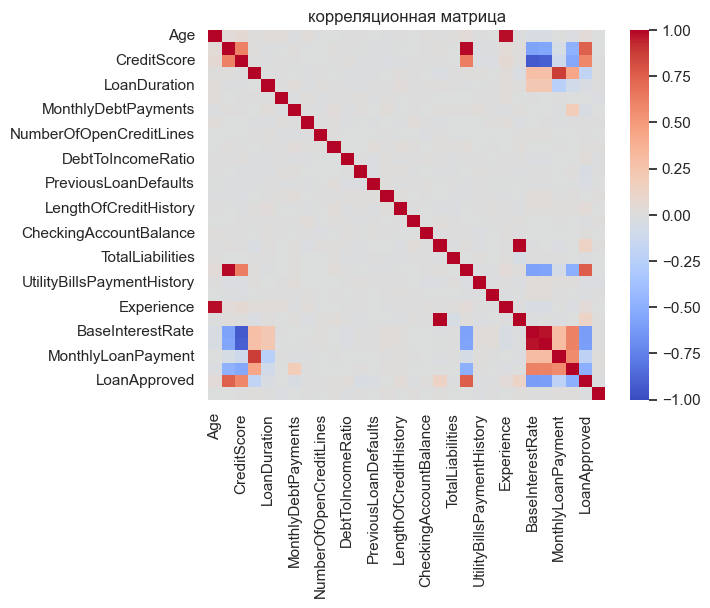

In [139]:
corr_matrix = new_train.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("корреляционная матрица")
plt.show()

<Axes: ylabel='Frequency'>

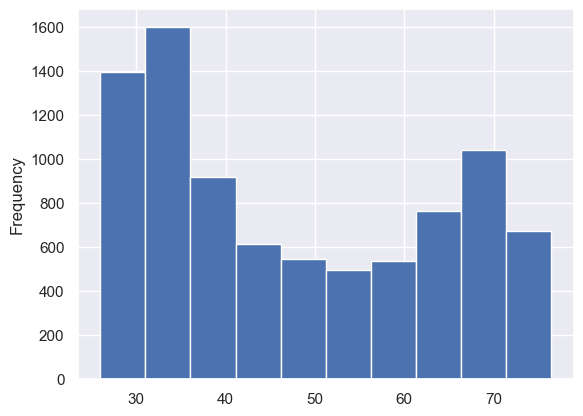

In [140]:
new_train = new_train[
    (new_train['RiskScore'] > new_train['RiskScore'].quantile(0.05)) &  
    (new_train['RiskScore'] < new_train['RiskScore'].quantile(0.95))]
new_train['RiskScore'].plot.hist()

In [141]:
x = new_train.drop(['RiskScore'], axis=1)
y = new_train['RiskScore']

In [142]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42)

Линейная регрессия

In [143]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [144]:
predict = lr_model.predict(X_test)

Ridge регрессия

In [145]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
predict = model.predict(X_test)

Lasso регрессия

In [146]:
lasso_model = Lasso(alpha=0.1) 
lasso_model.fit(X_train, y_train)
predict = model.predict(X_test)

In [147]:
def evaluate_model(model, name):
    predict = model.predict(X_test)
    mse = mean_squared_error(y_test, predict)
    print(f"{name} - MSE на тестовых данных: {mse}")
    return predict

In [148]:
linear_pred = evaluate_model(model, "linear regression")
lasso_pred = evaluate_model(lasso_model, "lasso regression")
ridge_pred = evaluate_model(ridge_model, "ridge regression")

linear regression - MSE на тестовых данных: 17.60747103846412
lasso regression - MSE на тестовых данных: 18.72769594097718
ridge regression - MSE на тестовых данных: 17.600776388760874


кросс-валидация

In [149]:
cross_valid = make_scorer(mean_squared_error)

In [150]:
def cross_validate_model(model, x, y, name):
    cv_sc = cross_val_score(model, x, y, cv=3, scoring=cross_valid)
    print(f"{name} - mse для каждого фолда: {cv_sc}")
    print(f"{name} - средний mse: {cv_sc.mean()}")

In [151]:
cross_validate_model(model, x, y, "linear regression")
cross_validate_model(lasso_model, x, y, "lasso regression")
cross_validate_model(ridge_model, x, y, "ridge regression")

linear regression - mse для каждого фолда: [18.1247124  16.79912587 18.00105125]
linear regression - средний mse: 17.641629838811323
lasso regression - mse для каждого фолда: [19.50331702 18.39720144 19.42824293]
lasso regression - средний mse: 19.10958713217853
ridge regression - mse для каждого фолда: [18.13208235 16.79934797 17.99073522]
ridge regression - средний mse: 17.640721845457495


графики истинных значений против предсказанных

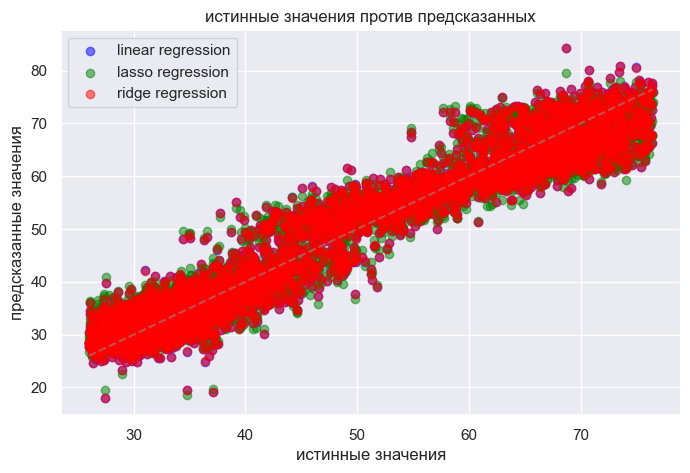

In [152]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, linear_pred, alpha=0.5, color='blue', label='linear regression')
plt.scatter(y_test, lasso_pred, alpha=0.5, color='green', label='lasso regression')
plt.scatter(y_test, ridge_pred, alpha=0.5, color='red', label='ridge regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('истинные значения')
plt.ylabel('предсказанные значения')
plt.title('истинные значения против предсказанных')
plt.legend()
plt.show()

топ 3 лучших получившихся результатов

In [153]:
linear_pred = evaluate_model(model, "linear regression")
lasso_pred = evaluate_model(lasso_model, "lasso regression")
ridge_pred = evaluate_model(ridge_model, "ridge regression")

linear regression - MSE на тестовых данных: 17.60747103846412
lasso regression - MSE на тестовых данных: 18.72769594097718
ridge regression - MSE на тестовых данных: 17.600776388760874
